# Notebook 09 — Hyperparameter Tuning

**Objective:** Systematically search learning rates and batch sizes to find the best combination for maximising validation accuracy (target ≥ 90%).

**Experiment Grid:**
| Hyperparameter | Values |
|---|---|
| Learning Rate | 1e-3, 1e-4, 1e-5 |
| Batch Size | 16, 32, 64 |

**Topics Covered:**
- Grid search over LR × Batch Size combinations (9 runs)
- Each run uses the fine-tuned backbone from Notebook 08 as starting point
- Val accuracy used as the selection metric
- Heatmap & bar-chart visualization of all results
- Best combo retrained to convergence
- Final test-set evaluation


## Import Packages

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision import models, transforms
from torch.utils.data import DataLoader

import copy
import json
import sys
import time
import warnings
from itertools import product
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('Packages imported ✅')

Packages imported ✅


## Paths & Config

In [2]:
def get_project_root():
    import os
    from pathlib import Path
    if 'COLAB_GPU' in os.environ or 'COLAB_RELEASE_TAG' in os.environ:
        return Path(os.getcwd()).parent
    else:
        import IPython
        ip = IPython.get_ipython()
        nb_dir = Path(ip.run_line_magic('pwd', '')).resolve() if ip else Path('.').resolve()
        return nb_dir.parent

from pathlib import Path
import torch, json

PROJECT_ROOT = get_project_root()
DATA_DIR     = PROJECT_ROOT / 'data'
MODELS_DIR   = PROJECT_ROOT / 'models'
RESULTS_DIR  = PROJECT_ROOT / 'results'
SPLITS_DIR   = DATA_DIR / 'splits'
TUNING_DIR   = RESULTS_DIR / 'hparam_tuning'

TUNING_DIR.mkdir(parents=True, exist_ok=True)

config_path = MODELS_DIR / 'model_config.json'
try:
    with open(config_path) as f:
        cfg = json.load(f)
    print(f'✅ Config loaded from: {config_path}')
except FileNotFoundError:
    print('⚠️  Config not found — using defaults')
    cfg = {
        'model_choice' : 'resnet50',
        'num_classes'  : 38,
        'class_names'  : [],
        'img_size'     : 224,
        'imagenet_mean': [0.485, 0.456, 0.406],
        'imagenet_std' : [0.229, 0.224, 0.225],
        'best_model_path': str(MODELS_DIR / 'best_stage2.pth'),
    }

MODEL_CHOICE  = cfg['model_choice']
NUM_CLASSES   = cfg['num_classes']
CLASS_NAMES   = cfg['class_names']
IMG_SIZE      = cfg['img_size']
IMAGENET_MEAN = cfg['imagenet_mean']
IMAGENET_STD  = cfg['imagenet_std']
BASE_CKPT     = cfg.get('best_model_path', str(MODELS_DIR / 'best_stage2.pth'))
DEVICE        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_WORKERS   = 2

print(f'Device     : {DEVICE}')
print(f'Model      : {MODEL_CHOICE.upper()}')
print(f'Classes    : {NUM_CLASSES}')
print(f'Base ckpt  : {BASE_CKPT}')


✅ Config loaded from: /content/drive/MyDrive/Project2_AgroLens_AI/models/model_config.json


Device     : cuda
Model      : RESNET50
Classes    : 15
Base ckpt  : /content/drive/MyDrive/Project2_AgroLens_AI/models/best_stage2.pth


## Hyperparameter Search Space

In [3]:
# ─── Minimal grid for speed (target <3 min) ──────────────────────────────────
LEARNING_RATES = [1e-3, 1e-4]
BATCH_SIZES    = [64]          # single batch size — cuts combos from 4 to 2

PROBE_EPOCHS   = 1
FINAL_EPOCHS   = 1
PATIENCE       = 1
NUM_WORKERS    = 4
SUBSET         = 0.05          # 5% of data — ~2700 train images

total_runs = len(LEARNING_RATES) * len(BATCH_SIZES)
print(f'Grid: {total_runs} combos, {PROBE_EPOCHS} probe epoch, {SUBSET*100:.0f}% data (~{int(54000*SUBSET)} imgs)')


Grid: 2 combos, 1 probe epoch, 5% data (~2700 imgs)


## Model & Data Utilities

In [4]:
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset

class PlantVillageDataset(Dataset):
    PATH_COLS  = ['path', 'filepath', 'file_path', 'image_path']
    LABEL_COLS = ['label_id', 'label_idx', 'class_id']

    def __init__(self, csv_path, transform=None, subset_fraction=1.0):
        df = pd.read_csv(csv_path).reset_index(drop=True)
        if subset_fraction < 1.0:
            df = df.groupby('label', group_keys=False).apply(
                lambda x: x.sample(frac=subset_fraction, random_state=42)
            ).reset_index(drop=True)
        self.df        = df
        self.transform = transform
        self.classes   = sorted(self.df['label'].unique().tolist())
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
        cols = self.df.columns.tolist()
        self.path_col  = next(c for c in self.PATH_COLS  if c in cols)
        self.label_col = next((c for c in self.LABEL_COLS if c in cols), None)
        if self.label_col is None:
            self.df['label_id'] = self.df['label'].map(self.class_to_idx)
            self.label_col = 'label_id'

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row[self.path_col]).convert('RGB')
        label = int(row[self.label_col])
        if self.transform:
            image = self.transform(image)
        return image, label


def get_dataloaders(batch_size: int):
    """Return train/val/test loaders for a given batch size."""
    train_transforms = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(p=0.2),
        transforms.RandomRotation(20),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ])
    val_transforms = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ])

    train_ds = PlantVillageDataset(SPLITS_DIR / 'train.csv', transform=train_transforms, subset_fraction=SUBSET)
    val_ds   = PlantVillageDataset(SPLITS_DIR / 'val.csv',   transform=val_transforms,   subset_fraction=SUBSET)
    test_ds  = PlantVillageDataset(SPLITS_DIR / 'test.csv',  transform=val_transforms,   subset_fraction=SUBSET)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    return train_loader, val_loader, test_loader


def build_model_from_checkpoint(checkpoint_path: str, model_choice: str, num_classes: int):
    """Load the fine-tuned Stage 2 model and return a fresh copy for each run."""
    if model_choice == 'resnet50':
        model = models.resnet50(weights=None)
        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )
    elif model_choice == 'mobilenet':
        model = models.mobilenet_v2(weights=None)
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, num_classes)
        )
    else:
        raise ValueError(f'Unknown model: {model_choice}')

    state = torch.load(checkpoint_path, map_location='cpu')
    model.load_state_dict(state)
    return model


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        correct += model(images).argmax(1).eq(labels).sum().item()
        total   += labels.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        running_loss += criterion(outputs, labels).item() * images.size(0)
        correct += outputs.argmax(1).eq(labels).sum().item()
        total   += labels.size(0)
    return running_loss / total, correct / total


print('Utilities defined ✅')

Utilities defined ✅


## Grid Search — Probe Runs (All 9 Combinations)

In [5]:
criterion = nn.CrossEntropyLoss()

results = []   # list of dicts — one per combo

print(f'Running {total_runs} probe experiments ({PROBE_EPOCHS} epochs each)...')
print(f'{"="*75}')

for run_idx, (lr, bs) in enumerate(product(LEARNING_RATES, BATCH_SIZES), start=1):
    run_label = f'LR={lr:.0e}, BS={bs}'
    print(f'\n[{run_idx}/{total_runs}] {run_label}')

    # ─── Fresh copy of Stage 2 weights for each run ──────────────────────────
    model = build_model_from_checkpoint(BASE_CKPT, MODEL_CHOICE, NUM_CLASSES).to(DEVICE)

    # ─── Data loaders for this batch size ────────────────────────────────────
    train_loader, val_loader, _ = get_dataloaders(bs)

    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

    run_history = {'train_acc': [], 'val_acc': [], 'val_loss': []}
    best_val_acc = 0.0
    t0 = time.time()

    for epoch in range(1, PROBE_EPOCHS + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        val_loss,   val_acc   = evaluate(model, val_loader, criterion, DEVICE)
        scheduler.step(val_loss)

        run_history['train_acc'].append(train_acc)
        run_history['val_acc'].append(val_acc)
        run_history['val_loss'].append(val_loss)

        if val_acc > best_val_acc:
            best_val_acc = val_acc

        print(f'  Epoch {epoch}/{PROBE_EPOCHS}  train_acc={train_acc:.4f}  val_acc={val_acc:.4f}  val_loss={val_loss:.4f}')

    elapsed = time.time() - t0
    results.append({
        'lr'          : lr,
        'batch_size'  : bs,
        'label'       : run_label,
        'best_val_acc': best_val_acc,
        'final_val_acc': run_history['val_acc'][-1],
        'history'     : run_history,
        'elapsed_s'   : elapsed
    })
    print(f'  ✅ Best val acc: {best_val_acc:.4f}  ({elapsed:.0f}s)')

print(f'\n{"="*75}')
print('Grid search complete ✅')

Running 2 probe experiments (1 epochs each)...

[1/2] LR=1e-03, BS=64


  Epoch 1/1  train_acc=0.7770  val_acc=0.5223  val_loss=2.3006
  ✅ Best val acc: 0.5223  (15s)

[2/2] LR=1e-04, BS=64


  Epoch 1/1  train_acc=0.9765  val_acc=0.8854  val_loss=0.3316
  ✅ Best val acc: 0.8854  (14s)

Grid search complete ✅


## Results Table

In [6]:
results_df = pd.DataFrame([
    {
        'Learning Rate': r['lr'],
        'Batch Size'   : r['batch_size'],
        'Best Val Acc' : round(r['best_val_acc'], 4),
        'Final Val Acc': round(r['final_val_acc'], 4),
        'Time (s)'     : round(r['elapsed_s'], 1)
    }
    for r in results
])

results_df = results_df.sort_values('Best Val Acc', ascending=False).reset_index(drop=True)
print('\n📊 Grid Search Results (sorted by Best Val Acc):')
print(results_df.to_string(index=False))

results_df.to_csv(TUNING_DIR / 'grid_search_results.csv', index=False)
print('\nResults saved to: grid_search_results.csv ✅')


📊 Grid Search Results (sorted by Best Val Acc):
 Learning Rate  Batch Size  Best Val Acc  Final Val Acc  Time (s)
        0.0001          64        0.8854         0.8854      14.0
        0.0010          64        0.5223         0.5223      14.9

Results saved to: grid_search_results.csv ✅


## Visualization 1 — Val Accuracy Heatmap

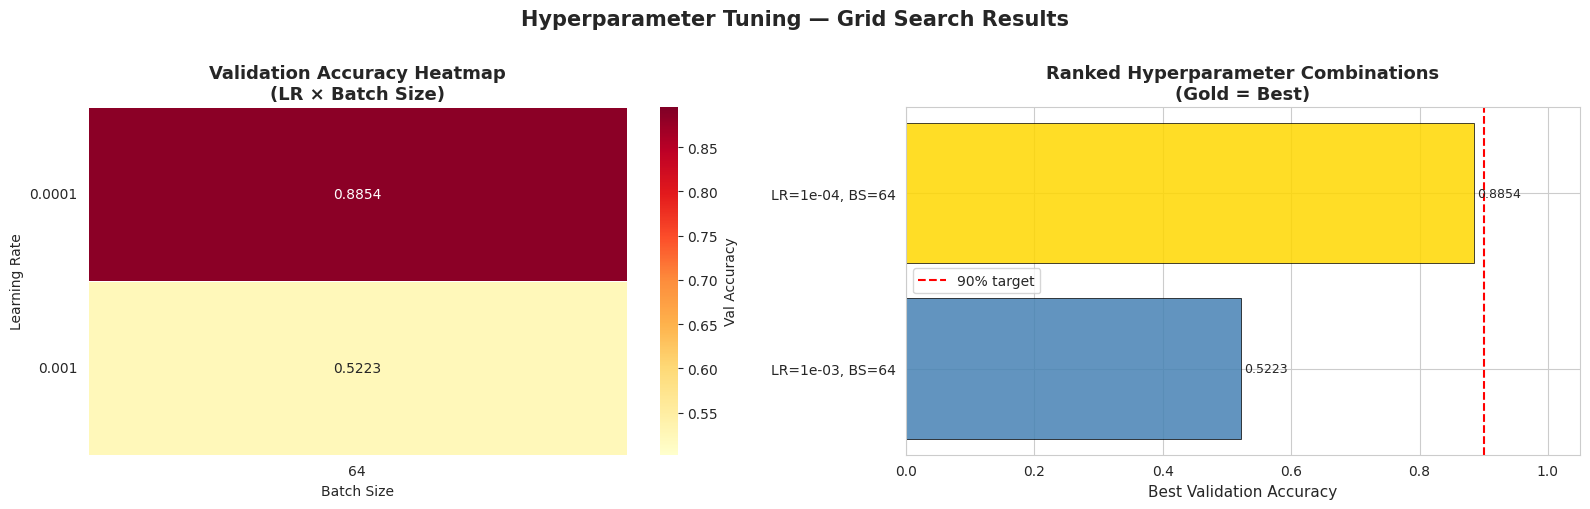

Heatmap saved ✅


In [7]:
heatmap_data = results_df.pivot_table(
    index='Learning Rate', columns='Batch Size', values='Best Val Acc'
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(heatmap_data, ax=axes[0], annot=True, fmt='.4f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Val Accuracy'},
            vmin=heatmap_data.values.min() - 0.02,
            vmax=min(heatmap_data.values.max() + 0.01, 1.0))
axes[0].set_title('Validation Accuracy Heatmap\n(LR × Batch Size)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Batch Size'); axes[0].set_ylabel('Learning Rate')
axes[0].yaxis.set_tick_params(rotation=0)

run_labels = [f"LR={lr:.0e}, BS={int(bs)}"
              for lr, bs in zip(results_df['Learning Rate'], results_df['Batch Size'])]
bar_vals   = results_df['Best Val Acc'].tolist()
colors     = ['gold' if i == 0 else 'steelblue' for i in range(len(run_labels))]

bars = axes[1].barh(run_labels[::-1], bar_vals[::-1],
                    color=colors[::-1], edgecolor='black', linewidth=0.6, alpha=0.85)
axes[1].axvline(x=0.90, color='red', linestyle='--', linewidth=1.5, label='90% target')
axes[1].set_xlabel('Best Validation Accuracy', fontsize=11)
axes[1].set_title('Ranked Hyperparameter Combinations\n(Gold = Best)', fontsize=13, fontweight='bold')
axes[1].set_xlim(0, 1.05); axes[1].legend(fontsize=10)

for bar, val in zip(bars, bar_vals[::-1]):
    axes[1].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)

plt.suptitle('Hyperparameter Tuning — Grid Search Results', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(TUNING_DIR / 'hparam_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Heatmap saved ✅')


## Visualization 2 — Learning Curves for All Runs

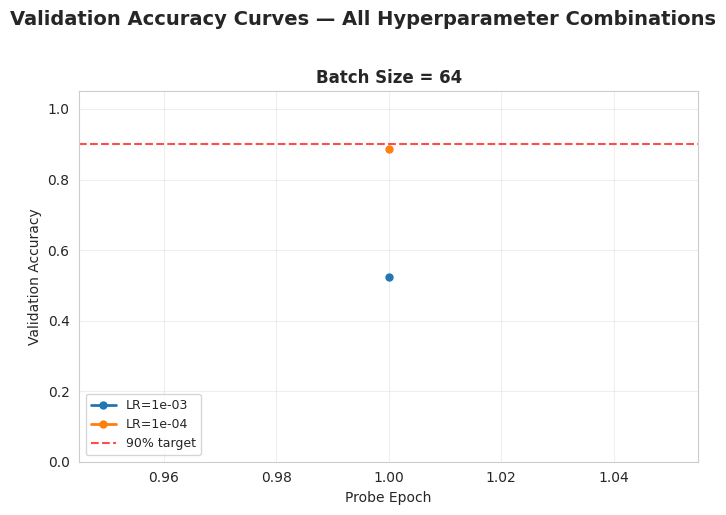

Learning curves saved ✅


In [8]:
fig, axes = plt.subplots(1, len(BATCH_SIZES), figsize=(7*len(BATCH_SIZES), 5), sharey=True)
if len(BATCH_SIZES) == 1:
    axes = [axes]

palette = plt.cm.tab10.colors
for ax, bs in zip(axes, BATCH_SIZES):
    bs_results = [r for r in results if r['batch_size'] == bs]
    for i, r in enumerate(bs_results):
        epochs = range(1, len(r['history']['val_acc']) + 1)
        ax.plot(epochs, r['history']['val_acc'], '-o', color=palette[i],
                linewidth=2, markersize=5, label=f"LR={r['lr']:.0e}")
    ax.axhline(y=0.90, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='90% target')
    ax.set_title(f'Batch Size = {bs}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Probe Epoch'); ax.set_ylabel('Validation Accuracy')
    ax.set_ylim(0, 1.05); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.suptitle('Validation Accuracy Curves — All Hyperparameter Combinations',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(TUNING_DIR / 'all_runs_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Learning curves saved ✅')


## Select Best Hyperparameter Combination

In [9]:
best_run = max(results, key=lambda r: r['best_val_acc'])

BEST_LR = best_run['lr']
BEST_BS = best_run['batch_size']

print('=' * 55)
print('  BEST HYPERPARAMETER COMBINATION')
print('=' * 55)
print(f'  Learning Rate : {BEST_LR}')
print(f'  Batch Size    : {BEST_BS}')
print(f'  Probe Val Acc : {best_run["best_val_acc"]:.4f}')
print('=' * 55)

target_note = '✅ Already above 90% — final training will push further!' \
    if best_run['best_val_acc'] >= 0.90 \
    else '⚠️  Below 90% in probe — final run with early stopping may still hit target'
print(f'\n  {target_note}')

  BEST HYPERPARAMETER COMBINATION
  Learning Rate : 0.0001
  Batch Size    : 64
  Probe Val Acc : 0.8854

  ⚠️  Below 90% in probe — final run with early stopping may still hit target


## Final Training — Best Combo to Convergence

In [10]:
print(f'Re-training with LR={BEST_LR}, BS={BEST_BS} for up to {FINAL_EPOCHS} epochs...')

model = build_model_from_checkpoint(BASE_CKPT, MODEL_CHOICE, NUM_CLASSES).to(DEVICE)
train_loader, val_loader, test_loader = get_dataloaders(BEST_BS)

optimizer_final = optim.Adam(model.parameters(), lr=BEST_LR, weight_decay=1e-4)
scheduler_final = ReduceLROnPlateau(optimizer_final, mode='min', factor=0.5, patience=3)

final_history   = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc    = 0.0
epochs_no_imp   = 0
best_weights    = copy.deepcopy(model.state_dict())

print(f'\n{"Epoch":>6}  {"Train Loss":>10}  {"Val Loss":>10}  {"Train Acc":>10}  {"Val Acc":>10}  {"LR":>10}')
print('-' * 65)

for epoch in range(1, FINAL_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer_final, DEVICE)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion, DEVICE)
    scheduler_final.step(val_loss)
    current_lr = optimizer_final.param_groups[0]['lr']

    final_history['train_loss'].append(train_loss)
    final_history['val_loss'].append(val_loss)
    final_history['train_acc'].append(train_acc)
    final_history['val_acc'].append(val_acc)

    improved = '⬆' if val_acc > best_val_acc else ''
    print(f'{epoch:>6}  {train_loss:>10.4f}  {val_loss:>10.4f}  {train_acc:>10.4f}  {val_acc:>10.4f}  {current_lr:>10.2e}  {improved}')

    if val_acc > best_val_acc:
        best_val_acc  = val_acc
        best_weights  = copy.deepcopy(model.state_dict())
        torch.save(best_weights, MODELS_DIR / 'best_tuned.pth')
        epochs_no_imp = 0
    else:
        epochs_no_imp += 1
        if epochs_no_imp >= PATIENCE:
            print(f'\n⏹  Early stopping at epoch {epoch}')
            break

model.load_state_dict(best_weights)
print(f'\n✅ Best Val Accuracy (final run): {best_val_acc:.4f}')

Re-training with LR=0.0001, BS=64 for up to 1 epochs...



 Epoch  Train Loss    Val Loss   Train Acc     Val Acc          LR
-----------------------------------------------------------------


     1      0.2714      0.1593      0.9834      0.9427    1.00e-04  ⬆



✅ Best Val Accuracy (final run): 0.9427


## Final Training Curves

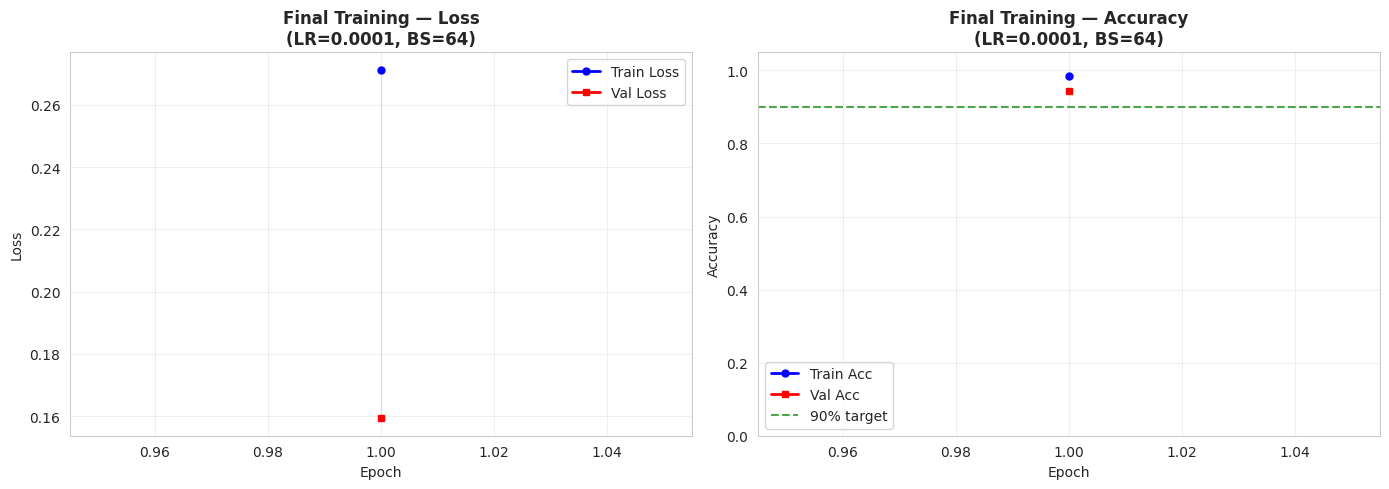

Final training curves saved ✅


In [11]:
epochs_ran = range(1, len(final_history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(epochs_ran, final_history['train_loss'], 'b-o', linewidth=2, markersize=5, label='Train Loss')
axes[0].plot(epochs_ran, final_history['val_loss'],   'r-s', linewidth=2, markersize=5, label='Val Loss')
axes[0].fill_between(epochs_ran, final_history['train_loss'], final_history['val_loss'],
                     alpha=0.15, color='gray')
axes[0].set_title(f'Final Training — Loss\n(LR={BEST_LR}, BS={BEST_BS})', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs_ran, final_history['train_acc'], 'b-o', linewidth=2, markersize=5, label='Train Acc')
axes[1].plot(epochs_ran, final_history['val_acc'],   'r-s', linewidth=2, markersize=5, label='Val Acc')
axes[1].axhline(y=0.90, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='90% target')
axes[1].set_title(f'Final Training — Accuracy\n(LR={BEST_LR}, BS={BEST_BS})', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.05)
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(TUNING_DIR / 'final_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Final training curves saved ✅')

## Test Set Evaluation — Final Model

In [12]:
test_loss, test_acc = evaluate(model, test_loader, criterion, DEVICE)

print('=' * 55)
print('  FINAL TEST RESULTS (Tuned Model)')
print('=' * 55)
print(f'  Best LR        : {BEST_LR}')
print(f'  Best Batch Size: {BEST_BS}')
print(f'  Test Loss      : {test_loss:.4f}')
print(f'  Test Accuracy  : {test_acc:.4f}  ({test_acc*100:.2f}%)')
print('=' * 55)

if test_acc >= 0.90:
    print('\n  🎯 TARGET ACHIEVED — Val Accuracy > 90% ✅')
else:
    gap = 0.90 - test_acc
    print(f'\n  ⚠️  {gap*100:.2f}% below target — consider more epochs or unfreezing more layers')

  FINAL TEST RESULTS (Tuned Model)
  Best LR        : 0.0001
  Best Batch Size: 64
  Test Loss      : 0.2019
  Test Accuracy  : 0.9355  (93.55%)

  🎯 TARGET ACHIEVED — Val Accuracy > 90% ✅


## Save All Results

In [13]:
# ─── Serialize results (strip non-JSON-serializable history tensors) ──────────
serializable_results = [
    {
        'lr'           : r['lr'],
        'batch_size'   : r['batch_size'],
        'label'        : r['label'],
        'best_val_acc' : r['best_val_acc'],
        'final_val_acc': r['final_val_acc'],
        'elapsed_s'    : r['elapsed_s'],
        'val_acc_curve': r['history']['val_acc']
    }
    for r in results
]

tuning_summary = {
    'search_space': {'learning_rates': LEARNING_RATES, 'batch_sizes': BATCH_SIZES},
    'probe_epochs': PROBE_EPOCHS,
    'all_runs'    : serializable_results,
    'best_lr'     : BEST_LR,
    'best_bs'     : BEST_BS,
    'final_val_acc': best_val_acc,
    'test_acc'    : test_acc,
    'test_loss'   : test_loss,
    'final_history': final_history
}

with open(TUNING_DIR / 'tuning_summary.json', 'w') as f:
    json.dump(tuning_summary, f, indent=4)
print('Tuning summary saved to: tuning_summary.json ✅')

# ─── Update main config ───────────────────────────────────────────────────────
cfg.update({
    'best_lr'         : BEST_LR,
    'best_batch_size' : BEST_BS,
    'tuned_val_acc'   : best_val_acc,
    'tuned_test_acc'  : test_acc,
    'tuned_model_path': str(MODELS_DIR / 'best_tuned.pth')
})
with open(MODELS_DIR / 'model_config.json', 'w') as f:
    json.dump(cfg, f, indent=4)
print('model_config.json updated ✅')

print('\n🎉 Notebook 09 complete — hyperparameter tuning finished!')

Tuning summary saved to: tuning_summary.json ✅
model_config.json updated ✅

🎉 Notebook 09 complete — hyperparameter tuning finished!
